# Time Series Analysis - Traditional Methods

This notebook demonstrates classical statistical approaches to **time series forecasting** and **anomaly detection** using meteorological data.

**Methods covered:**
1. Anomaly detection: Z-Score on residuals, IQR detector
2. ARIMA family: AR, MA, ARMA, SARIMA, AutoARIMA
3. Exponential Smoothing: Holt-Winters (additive trend + seasonality)
4. State Space Models: Kalman filter with and without covariates

All forecasting targets **weekly mean temperature** (`temperature_air_mean_2m`), trained on 1975–2022 and evaluated on 2023–2024.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from darts import TimeSeries

import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

## Load Data

In [3]:
df_full = pd.read_csv("data/dwd_02932_climate.csv", sep=";", parse_dates=["date"], index_col="date")
df_full.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18263 entries, 1975-01-01 to 2024-12-31
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   wind_gust_max              18006 non-null  float64
 1   wind_speed                 18240 non-null  float64
 2   precipitation_height       18263 non-null  float64
 3   precipitation_form         18263 non-null  float64
 4   sunshine_duration          18082 non-null  float64
 5   snow_depth                 18233 non-null  float64
 6   cloud_cover_total          18263 non-null  float64
 7   pressure_vapor             18263 non-null  float64
 8   pressure_air_site          18263 non-null  float64
 9   temperature_air_mean_2m    18263 non-null  float64
 10  humidity                   18263 non-null  float64
 11  temperature_air_max_2m     18263 non-null  float64
 12  temperature_air_min_2m     18263 non-null  float64
 13  temperature_air_min_0_05m  18

For further analysis and forecasting, we select a subset of variables showing a high correlation with "temperature_air_mean_2m".  

We also include "precipitation_height" for outlier analysis.

In [4]:
df = df_full[["temperature_air_mean_2m", "precipitation_height", "pressure_vapor", "humidity"]]
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18263 entries, 1975-01-01 to 2024-12-31
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperature_air_mean_2m  18263 non-null  float64
 1   precipitation_height     18263 non-null  float64
 2   pressure_vapor           18263 non-null  float64
 3   humidity                 18263 non-null  float64
dtypes: float64(4)
memory usage: 713.4 KB


The dataset is loaded with 4 variables, all complete (no missing values at the daily level).

**Train / test split strategy:**
- Training: 1975–2022
- Test (forecast horizon): 2023–2024

> **Pitfall:**  
> The split must be strictly temporal without shuffling.  
> Any data from the test period used during fitting (even for scaling or feature engineering) constitutes **data leakage** and will produce optimistically biased evaluation metrics.

## Anomaly Detection

Detecting outliers *before* modelling is important: a single extreme value can distort model parameters significantly, especially in small-window calculations (moving averages, ACF estimates).

**Two complementary approaches are shown:**
- **Z-Score on residuals**: Deviation from the STL residual mean in standard deviations, assumes that residuals are roughly normal distributed
- **IQR detector**: Points outside `[Q1 − scale×IQR, Q3 + scale×IQR]`, Non-parametric, no distributional assumption


> **Pitfalls:**  
> - _Z-Score_: Applying Z-Score directly to a seasonal series (without decomposing first) flags seasonal peaks as anomalies. Always decompose and score the *residuals*, not the raw series.  
> - _IQR_: IQR is applied to the raw series here. For variables with strong seasonality, the interquartile range spans seasonal variation — the detector may miss genuine outliers in low-variance seasons.

### Z-Score

Anomaly Detection with Z-Score on Residuals

In [5]:
from statsmodels.tsa.seasonal import STL
from scipy.stats import zscore

df_prec = df[['precipitation_height']].copy()

# Extract residuals
df_prec['residuals'] = STL(df_prec, period=365).fit().resid

# Calculate z-scores for the residuals
df_prec['z_scores'] = zscore(df_prec['residuals'])

# Define a threshold for anomaly detection
z_score_threshold = 3  # Common threshold for detecting anomalies
df_prec['outliers'] = df_prec['z_scores'].abs() > z_score_threshold

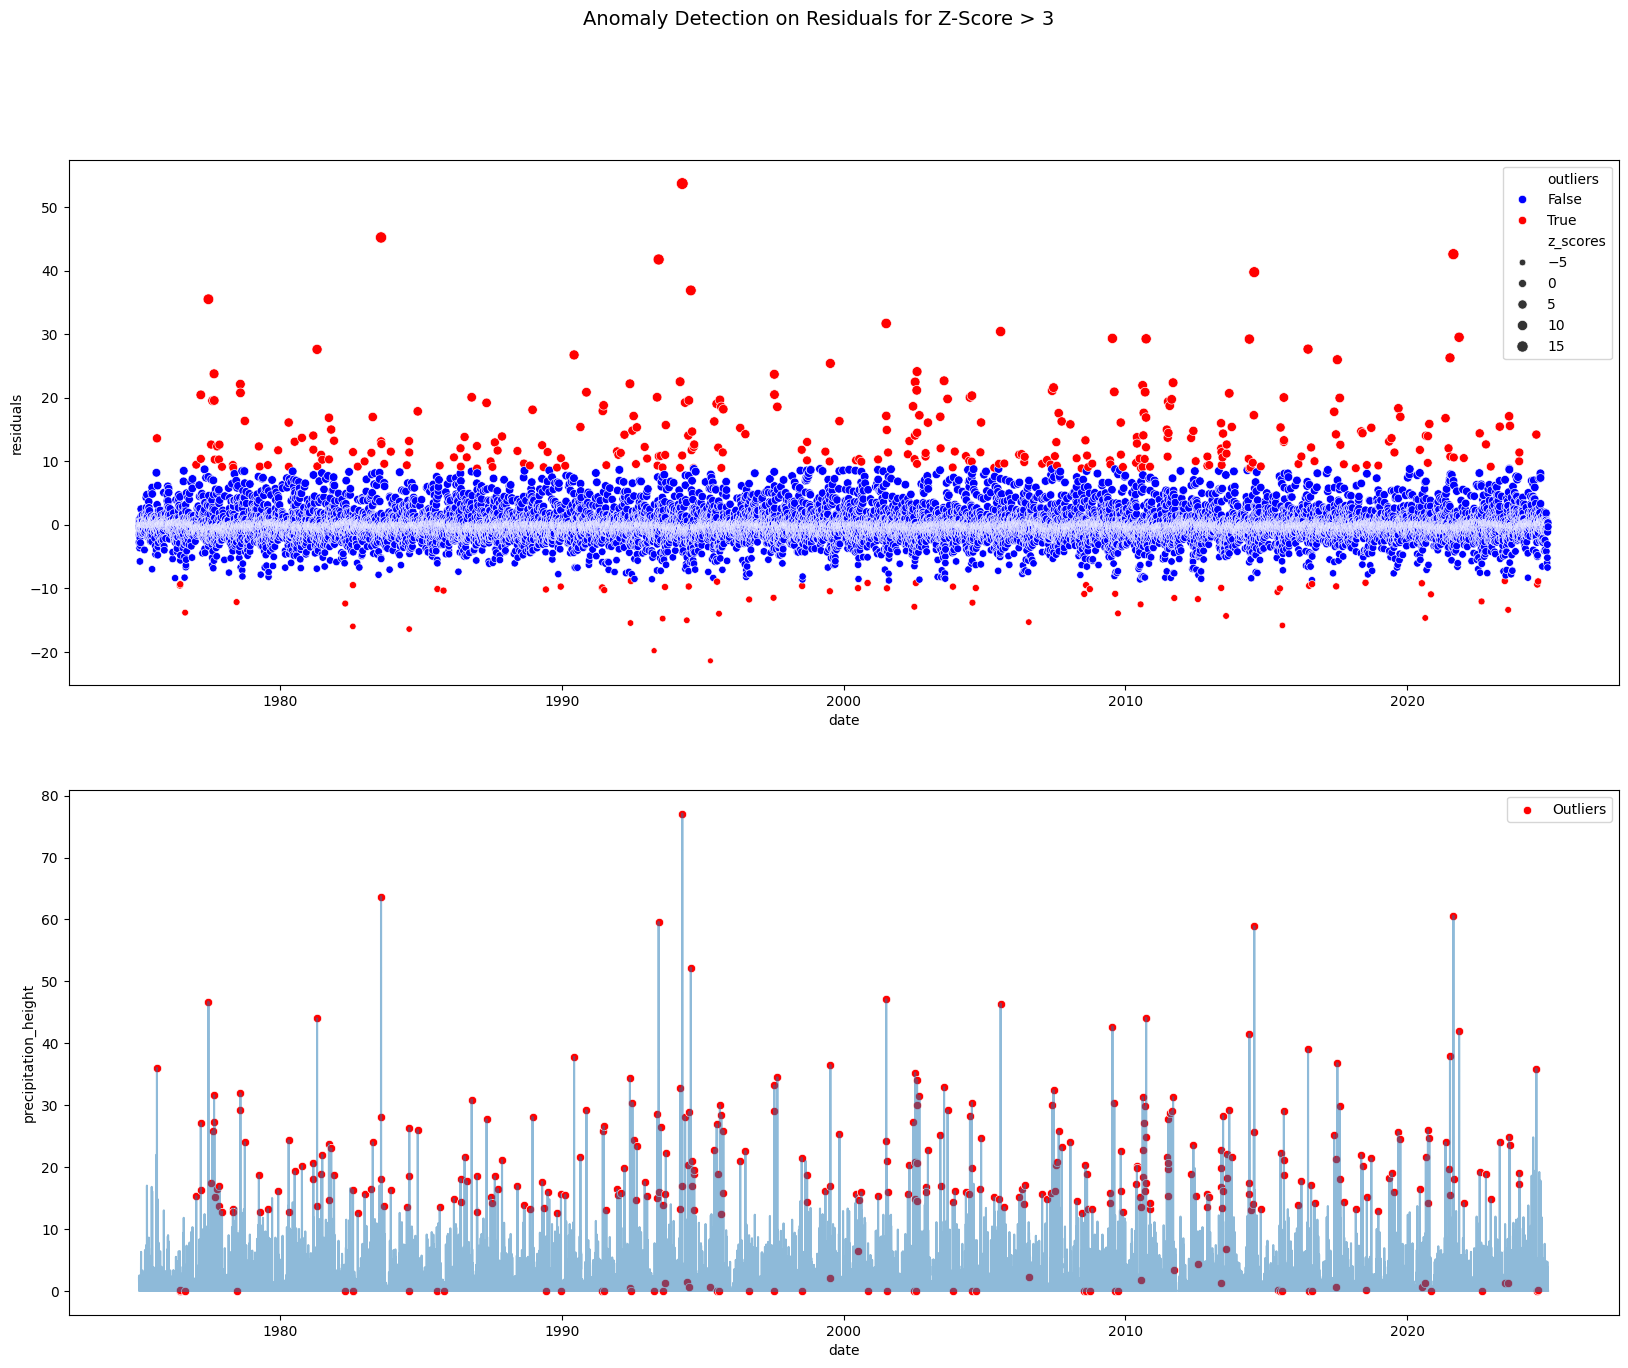

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(20, 15))
# Plot residuals with marked outliers
sns.scatterplot(data=df_prec, x=df_prec.index, y='residuals', hue='outliers', size='z_scores', 
                palette={True: 'red', False: 'blue'}, legend="brief", ax=ax[0])
# Plot timeseries with marked outliers
sns.lineplot(data=df_prec, x=df_prec.index, y='precipitation_height', alpha=0.5, ax=ax[1])
sns.scatterplot(x=df_prec.index[df_prec['outliers']], y=df_prec['precipitation_height'][df_prec['outliers']], 
                color='red', label='Outliers', ax=ax[1])
plt.suptitle('Anomaly Detection on Residuals for Z-Score > 3', fontsize=14)
plt.show()

### IQR Detector with darts

`IQRDetector` from darts implements the same IQR logic as a reusable fitted object that works directly with `TimeSeries`. The `scale` parameter multiplies the IQR to set how wide the non-anomaly band is (default = 1.5 as in Tukey's rule; `scale=3` is more conservative).

> **Pitfall:**  
> `fit_detect` fits the IQR bounds on the same data it detects. This is appropriate for exploratory analysis but **not** for a production pipeline where bounds should be fit on training data only, then applied to new data with `.detect()`.

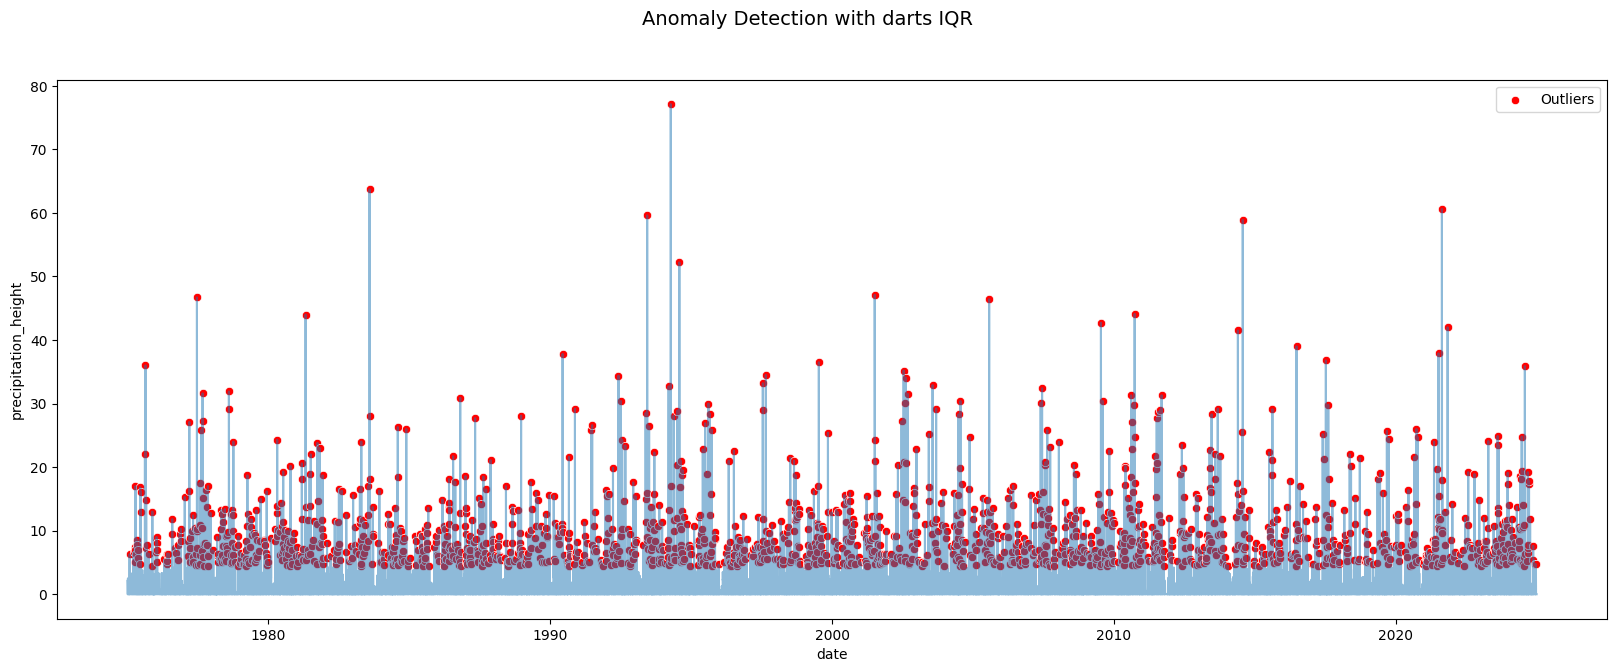

In [7]:
from darts.ad.detectors.iqr_detector import IQRDetector

series_prec = df['precipitation_height'].copy()

iqr_detector = IQRDetector(scale=3).fit_detect(TimeSeries.from_series(series_prec))
iqr_outliers = iqr_detector.to_dataframe().rename(columns={'precipitation_height': 'outliers'})['outliers'].astype('bool')

fig, ax = plt.subplots(figsize=(20, 7))
# Plot timeseries with marked outliers
sns.lineplot(x=series_prec.index, y=series_prec, alpha=0.5, ax=ax)
sns.scatterplot(x=series_prec.index[iqr_outliers], y=series_prec[iqr_outliers], color='red', label='Outliers', ax=ax)
plt.suptitle('Anomaly Detection with darts IQR', fontsize=14)
plt.show()

## Modeling and Forecasting with ARIMA Model Family

The ARIMA family models a time series using its own past values and past forecast errors:

| Model | Parameters | What it captures |
|-------|------------|-----------------|
| **AR(p)** | `p` lags | Autocorrelation - past values predict future values |
| **MA(q)** | `q` lags | Error smoothing - past forecast errors correct future predictions |
| **ARMA(p,q)** | `p`, `q` | Both simultaneously |
| **ARIMA(p,d,q)** | `p`, `d`, `q` | ARMA + `d` rounds of differencing to remove trend/non-stationarity |
| **SARIMA(p,d,q)(P,D,Q,s)** | + seasonal terms | Seasonal AR, MA, and differencing at period `s` |

**Choosing p, q:** ACF/PACF plots below guide order selection - PACF cuts off at lag `p` (AR), ACF cuts off at lag `q` (MA).

> **Pitfall:**  
> ARIMA assumes the series is (or can be made) stationary after `d` differences.  
> Seasonal patterns must be handled explicitly via SARIMA or prior decomposition, plain ARIMA on a seasonal series will produce poor forecasts.

We will use weekly resampled data for faster computation.

In [8]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

df_w = df.resample("W").mean()
df_w.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2610 entries, 1975-01-05 to 2025-01-05
Freq: W-SUN
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperature_air_mean_2m  2610 non-null   float64
 1   precipitation_height     2610 non-null   float64
 2   pressure_vapor           2610 non-null   float64
 3   humidity                 2610 non-null   float64
dtypes: float64(4)
memory usage: 102.0 KB


In [9]:

df_w_temp = df_w['temperature_air_mean_2m']

df_w_temp_train = df_w_temp.loc[:'2022']

print(df_w_temp_train.tail())

date
2022-11-27    3.614286
2022-12-04    1.714286
2022-12-11    0.600000
2022-12-18   -6.414286
2022-12-25    6.400000
Freq: W-SUN, Name: temperature_air_mean_2m, dtype: float64


### Order Selection via ACF / PACF

Before fitting any ARIMA-family model, inspect the ACF and PACF of the **training series** to guide `p` and `q` selection:

- **PACF cuts off sharply at lag p, ACF decays slowly**: AR(p)
- **ACF cuts off sharply at lag q, PACF decays slowly**: MA(q)
- **Both decay slowly**: ARMA(p, q), try small values of both

The ACF/PACF are plotted here on the **full series** (including test) for visual clarity, but in practice order selection should use training data only to avoid lookahead bias.

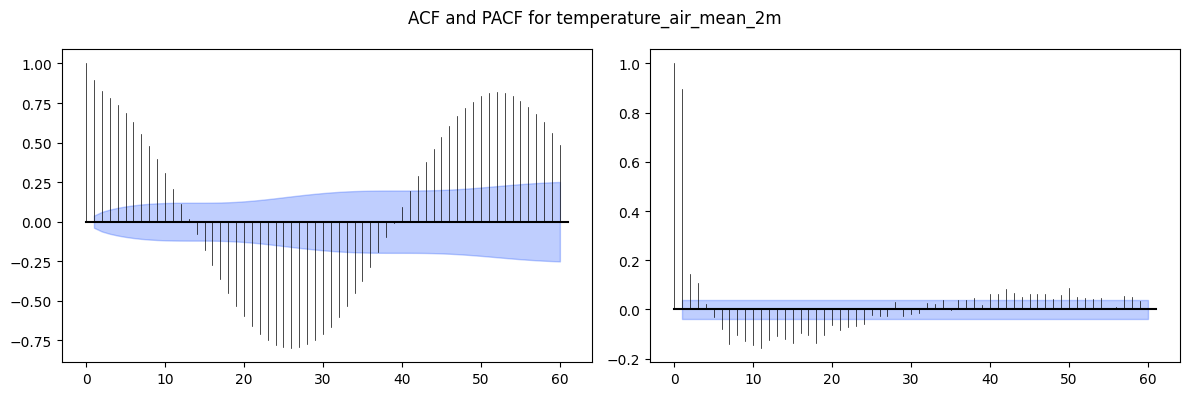

In [10]:
from darts.utils.statistics import plot_acf, plot_pacf

# Iterate over each column to plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
plot_acf(TimeSeries.from_series(df_w_temp), max_lag=60, alpha=0.05, axis=ax1)
plot_pacf(TimeSeries.from_series(df_w_temp), max_lag=60, alpha=0.05, axis=ax2)
plt.suptitle(f'ACF and PACF for {df_w_temp.name}')
plt.tight_layout()
plt.show()

In [11]:
p = 1
q = 3

#### Auto Regression (AR)

In [12]:

ar_model = AutoReg(df_w_temp_train, lags=p).fit()

#### Moving Average (MA)

In [13]:

ma_model = ARIMA(df_w_temp_train, order=(0, 0, q)).fit()

#### Autoregressive Moving Average (ARMA) - ARIMA with d=0 (no differencing)

In [14]:

arma_model = ARIMA(df_w_temp_train, order=(p, 0, q)).fit()


#### Seasonal Autoregressive Integrated Moving-Average (SARIMA)

In [15]:
P = 1
Q = 1
s = 52
sarima_model = SARIMAX(df_w_temp_train, order=(p, 0, q), seasonal_order=(P, 0, Q, s)).fit()

#### Generating Predictions

`predict(start, end)` with integer indices covers both:
- **In-sample fitted values** (start within training): shows how well the model fits the data it was trained on; this is *not* a measure of forecast quality
- **Out-of-sample forecasts** (end beyond training): the genuine test of generalization

The plot shows only 2021 onwards for visual clarity, but the models were trained on the full 1975–2022 history.

> **Pitfall:**  
> In-sample fit is almost always better than out-of-sample performance.  
> A model that looks perfect on the training window (e.g. SARIMA with many parameters) may still forecast poorly, always evaluate on held-out data.

In [16]:
start = len(df_w_temp.index) - 208
end = len(df_w_temp.index) - 1
ar_pred = ar_model.predict(start=start, end=end)
ma_pred = ma_model.predict(start=start, end=end)
arma_pred = arma_model.predict(start=start, end=end)
sarima_pred = sarima_model.predict(start=start, end=end)

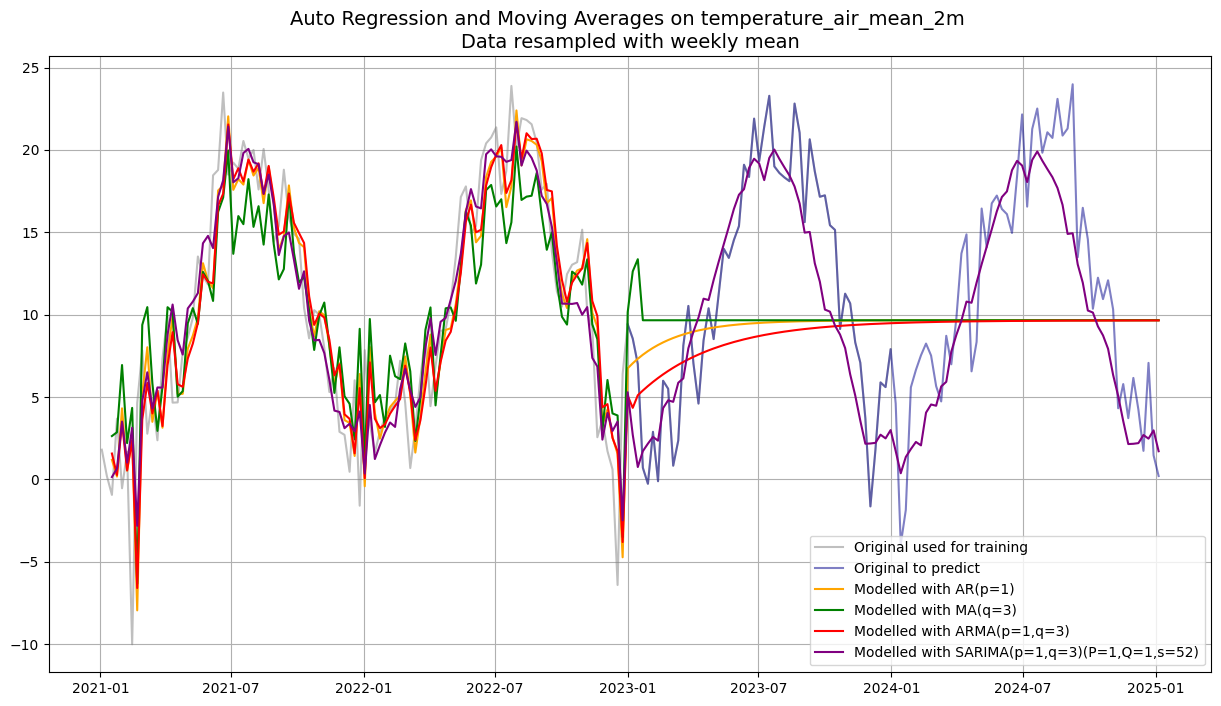

In [ ]:
plt.figure(figsize=(15, 8))
plt.plot(df_w_temp.loc["2021":"2023"], label='Original used for training', color='grey', alpha=0.5)
plt.plot(df_w_temp.loc["2023":], label='Original to predict', color='darkblue', alpha=0.5)
plt.plot(ar_pred.loc["2021":], label=f'Modelled with AR(p={p})', color='orange')
plt.plot(ma_pred.loc["2021":], label=f'Modelled with MA(q={q})', color='green')
plt.plot(arma_pred.loc["2021":], label=f'Modelled with ARMA(p={p},q={q})', color='red')
plt.plot(sarima_pred.loc["2021":], label=f'Modelled with SARIMA(p={p},q={q})(P={P},Q={Q},s={s})', color='purple')
plt.title(f"Auto Regression and Moving Averages on {df_w_temp.name} \nData resampled with weekly mean", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

### AutoARIMA - Automated Order Selection

`AutoARIMA` wraps `pmdarima.auto_arima`, which performs a stepwise search over `(p, d, q)` and seasonal `(P, D, Q)` combinations, selecting the model with the lowest **AIC** (Akaike Information Criterion) by default.

**Advantages over manual selection:**
- Automatically determines the differencing order `d` via unit-root tests
- Tests seasonal and non-seasonal components together
- Deterministic and reproducible

> **Pitfall:**  
> AutoARIMA can be slow on long series with many seasonal candidates.  
> AIC minimisation does not guarantee best forecast accuracy, it penalises complexity but can still overfit.  
> Validate on the held-out test set regardless of the AIC-selected order.

In [18]:
from darts.models import AutoARIMA

temp_series_train = TimeSeries.from_series(df_w_temp_train)

autoarima_model = AutoARIMA(season_length=52)
autoarima_model.fit(temp_series_train)

autoarima_pred = autoarima_model.predict(104)

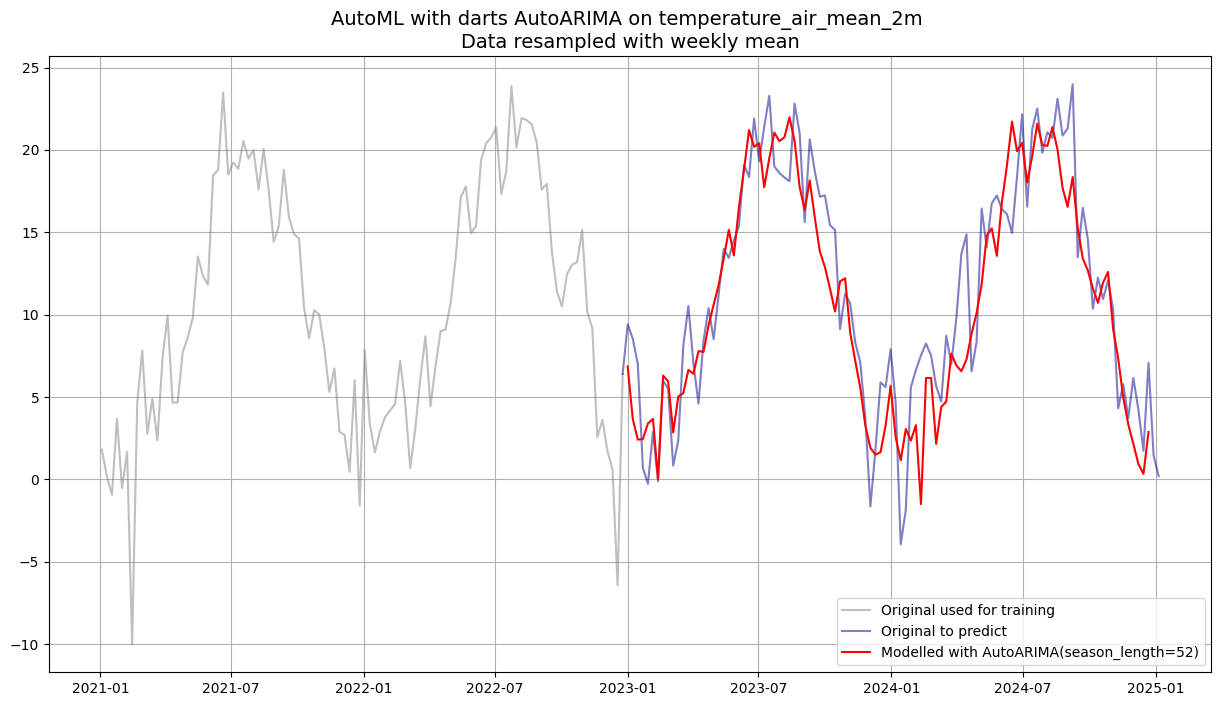

In [34]:
plt.figure(figsize=(15, 8))
plt.plot(df_w_temp.loc["2021":"2022"], label='Original used for training', color='grey', alpha=0.5)
plt.plot(df_w_temp.loc["2022-12-25":], label='Original to predict', color='darkblue', alpha=0.5)
plt.plot(autoarima_pred.to_series(), label='Modelled with AutoARIMA(season_length=52)', color='red')
plt.title(f"AutoML with darts AutoARIMA on {df_w_temp.name} \nData resampled with weekly mean", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

## Exponential Smoothing with Holt-Winters

Exponential smoothing models predict future values as a **weighted average of past observations**, where more recent observations receive higher weight. There are three levels of complexity:

| Model | Components | Parameters |
|-------|-----------|------------|
| Simple (SES) | Level only | `α` |
| Double (Holt) | Level + Trend | `α`, `β` |
| Triple (Holt-Winters) | Level + Trend + Seasonality | `α`, `β`, `γ` |

**Additive vs multiplicative seasonal:**
- **Additive:** seasonal fluctuation is constant in magnitude - suitable here (temperature amplitude is stable)
- **Multiplicative:** fluctuation grows with the level - typical for economic/sales data

Normally the smoothing weights are **optimised via MLE**. Here `smoothing_trend` and `smoothing_seasonal` are fixed at 0.4 to demonstrate the effect of a specific weighting.

> **Pitfall:**  
> Manually fixing smoothing weights prevents the model from adapting to the actual data dynamics.  
> A weight of 0.4 is quite high (strong recency bias) and may cause instability over a 2-year forecast horizon.  
> Let the model optimise the weights for production use.

In [20]:
from darts.models.forecasting.exponential_smoothing import ExponentialSmoothing
from darts.utils.utils import ModelMode, SeasonalityMode

# Create training data as TimeSeries
temp_series_train = TimeSeries.from_series(df_w_temp_train)

weight=0.4
model_exp = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE, 
    seasonal=SeasonalityMode.ADDITIVE, 
    seasonal_periods=52,
    smoothing_trend=weight,
    smoothing_seasonal=weight,)
model_exp.fit(temp_series_train)

ExponentialSmoothing(trend=ModelMode.ADDITIVE, damped=False, seasonal=SeasonalityMode.ADDITIVE, seasonal_periods=52, error=add, random_errors=None, random_state=None, kwargs=None, smoothing_trend=0.4, smoothing_seasonal=0.4)

In [21]:
exp_pred = model_exp.predict(104)

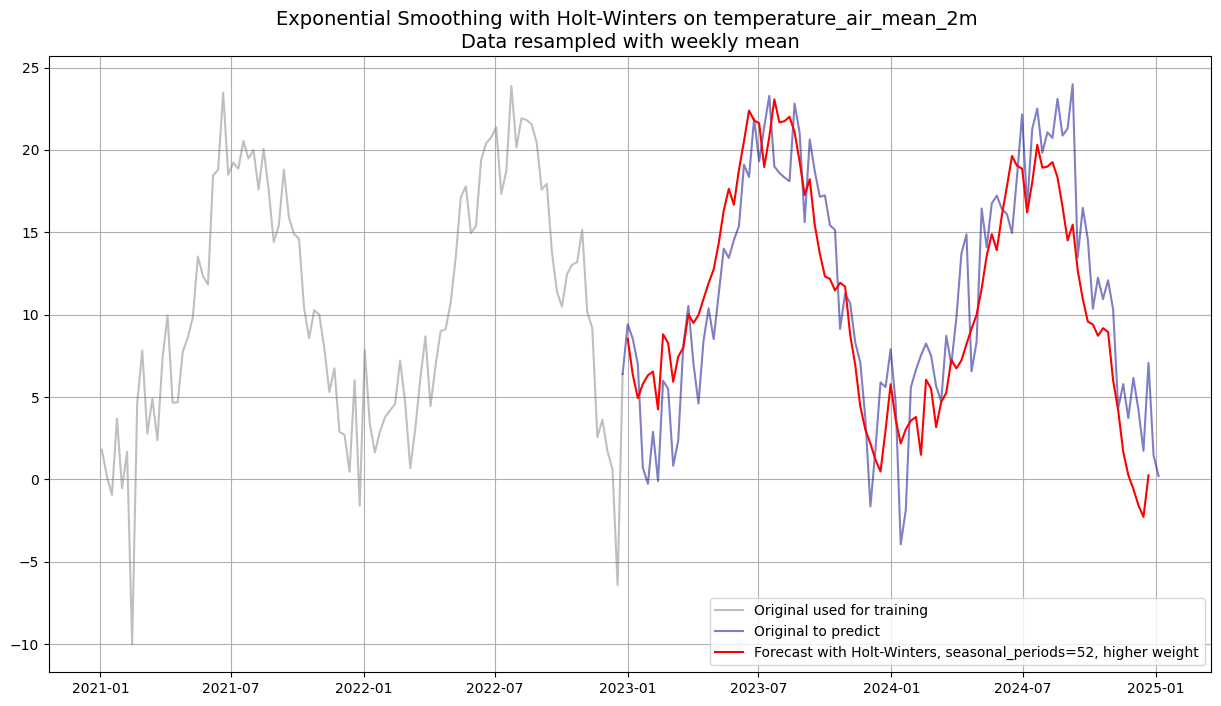

In [22]:
plt.figure(figsize=(15, 8))
plt.plot(df_w_temp.loc["2021":"2022"], label='Original used for training', color='grey', alpha=0.5)
plt.plot(df_w_temp.loc["2022-12-25":], label='Original to predict', color='darkblue', alpha=0.5)
plt.plot(exp_pred.to_series(), label=f'Forecast with Holt-Winters, seasonal_periods=52, higher weight', color='red')
plt.title(f"Exponential Smoothing with Holt-Winters on {df_w_temp.name} \nData resampled with weekly mean", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

## State Space Models with Kalman Filter

State space models represent a time series through a **hidden state vector** that evolves over time according to a transition equation. The Kalman filter is the optimal linear estimator of this hidden state.

**Key parameter `dim_x` (state vector size):**
- Small `dim_x` (e.g. 2): a compact model that captures basic dynamics (level + trend-like behaviour). Less flexible but more robust on limited data.
- Large `dim_x` (e.g. 35): can represent more complex latent structure (multiple frequency components, interactions). Prone to overfitting.

Four variants are compared: small/large state vector × with/without future covariates.

> **Pitfall:**  
> The Kalman filter assumes **linear, Gaussian** dynamics. It will not capture non-linear patterns.  
> Choosing `dim_x` is essentially a regularisation decision. There is no closed-form rule, cross-validate on the test set.

### Future Covariates - Cyclic Calendar Features

**Covariates** are additional input features that help explain the target series. *Future* covariates are features whose values are **known in advance** for the entire forecast horizon. Calendar features (month, day-of-week) are a natural choice.

**Why cyclic (sin/cos) encoding for month?**  
A plain integer encoding (1–12) treats month 1 and month 12 as maximally distant, but they are adjacent in the calendar. Sin/cos encoding maps the month onto a circle so that the distance between consecutive months (including Dec-Jan) is uniform.

> **Pitfall:**  
> Only use covariates that are genuinely available at prediction time.  
> Using covariates that depend on future target values (e.g. a lagged temperature from the test set) is a form of data leakage.

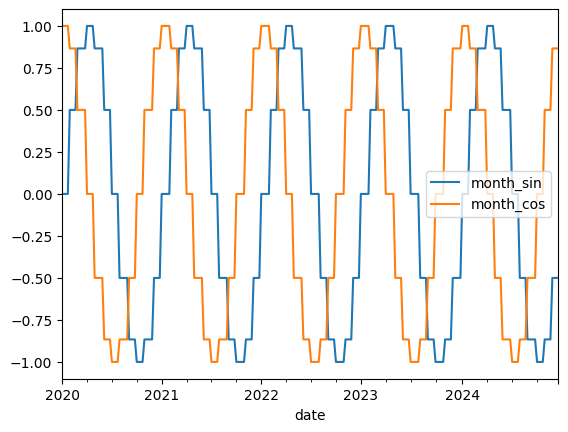

In [23]:
from darts.utils.timeseries_generation import datetime_attribute_timeseries

# Create training data as TimeSeries
temp_series_train = TimeSeries.from_series(df_w_temp_train)

# Create future covariates - month as sin / cos encoding projected 52 weeks into the future
future_cov = datetime_attribute_timeseries(temp_series_train, "month", cyclic=True, add_length=104)

future_cov.to_dataframe().loc["2020-01-01":].plot()
plt.show()

In [24]:

from darts.models.forecasting.kalman_forecaster import KalmanForecaster

# Fit Kalman models without covariates and predict the next 365 days
model_small = KalmanForecaster(dim_x=2)
model_small.fit(temp_series_train)
pred_small = model_small.predict(104)

model_big = KalmanForecaster(dim_x=35)
model_big.fit(temp_series_train)
pred_big = model_big.predict(104)

# Fit Kalman models with covariates and predict the next 365 days
model_small_cov = KalmanForecaster(dim_x=2)
model_small_cov.fit(temp_series_train, future_covariates=future_cov)
pred_small_cov = model_small_cov.predict(104, future_covariates=future_cov)

model_big_cov = KalmanForecaster(dim_x=35)
model_big_cov.fit(temp_series_train, future_covariates=future_cov)
pred_big_cov = model_big_cov.predict(104, future_covariates=future_cov)

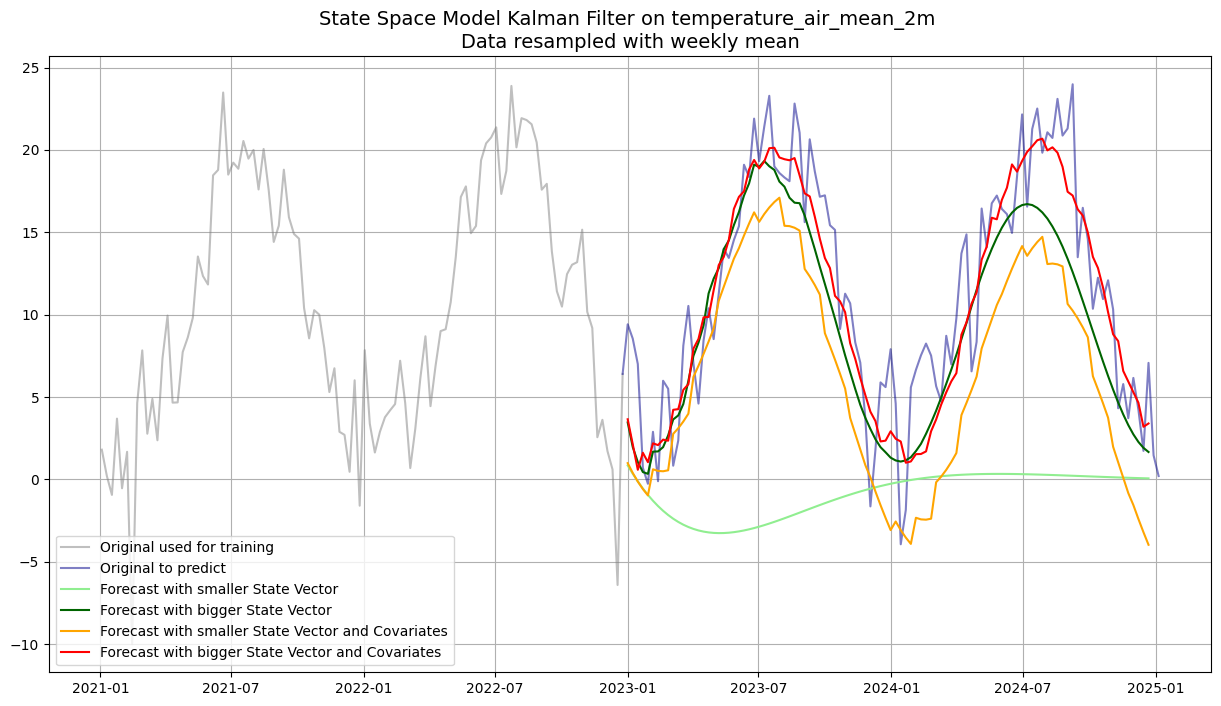

In [25]:
plt.figure(figsize=(15, 8))
plt.plot(df_w_temp.loc["2021":"2022"], label='Original used for training', color='grey', alpha=0.5)
plt.plot(df_w_temp.loc["2022-12-25":], label='Original to predict', color='darkblue', alpha=0.5)
plt.plot(pred_small.to_series(), label=f'Forecast with smaller State Vector', color='lightgreen')
plt.plot(pred_big.to_series(), label=f'Forecast with bigger State Vector', color='darkgreen')
plt.plot(pred_small_cov.to_series(), label=f'Forecast with smaller State Vector and Covariates', color='orange')
plt.plot(pred_big_cov.to_series(), label=f'Forecast with bigger State Vector and Covariates', color='red')
plt.title(f"State Space Model Kalman Filter on {df_w_temp.name} \nData resampled with weekly mean", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()